In [27]:
import scanpy as sc

In [2]:
adata_map = sc.read_h5ad("/nfs/home/students/m.back/swarm/backend/uploads/job_1773308453583_d28cf2eb-28cd-49e0-8ec3-d1871c00d0eb/kackhaufen1/adata_map.h5ad")

In [4]:
adata_map.var.head()

,in_tissue,array_row,array_col,pathologist_annotation,B-cells,CAFs,Cancer Epithelial,Endothelial,Myeloid,Normal Epithelial,...,global_outliers,log1p_total_counts_z,log1p_total_counts_outliers,log1p_n_genes_by_counts_z,log1p_n_genes_by_counts_outliers,pct_counts_mt_z,pct_counts_mt_outliers,local_outliers,uniform_density,rna_count_based_density
AAACCGGGTAGGTACC-1,1,42,28,Adipose tissue,0.076998,0.645444,6.846899e-13,0.102796,1.273444e-01,3.394147e-12,...,False,0.499680,False,0.607751,False,-0.132932,False,False,0.000784,0.000849
AAACCGTTCGTCCAGG-1,1,52,42,Fibrosis,0.429974,0.283151,4.763192e-13,0.089270,3.890135e-02,1.273346e-01,...,False,0.754912,False,0.836521,False,-6.821667,False,False,0.000784,0.000926
AAACCTCATGAAGTTG-1,1,37,19,<NA>,0.234456,0.623560,1.294380e-12,0.051878,7.889010e-03,2.638741e-02,...,False,0.226059,False,0.164638,False,-1.276950,False,False,0.000784,0.000669
AAACGAGACGGTTGAT-1,1,35,79,Fibrosis,0.398729,0.204462,5.587884e-13,0.037272,1.759830e-12,3.374678e-01,...,False,1.024507,False,0.984986,False,-0.009293,False,False,0.000784,0.000802
AAACTGCTGGCTCCAA-1,1,45,67,Fibrosis,0.317247,0.117703,8.046805e-13,0.074632,2.241093e-02,4.278375e-01,...,False,0.023397,False,-0.208662,False,-1.003031,False,False,0.000784,0.000894


In [5]:
adata_tg = sc.read_h5ad("/nfs/home/students/m.back/swarm/backend/uploads/job_1773308453583_d28cf2eb-28cd-49e0-8ec3-d1871c00d0eb/kackhaufen1/adata_tg_scores.h5ad")

In [6]:
adata_tg.obs["cell_type"]

AAACCGGGTAGGTACC-1         fibroblast
AAACCGTTCGTCCAGG-1             B cell
AAACCTCATGAAGTTG-1         fibroblast
AAACGAGACGGTTGAT-1             B cell
AAACTGCTGGCTCCAA-1    epithelial cell
                           ...       
TTGTACACCTCGAACA-1             B cell
TTGTCACCGCGGTATC-1             B cell
TTGTCGTTCAGTTACC-1         fibroblast
TTGTGTTTCCCGAAAG-1             B cell
TTGTTGTGTGTCAAGA-1    epithelial cell
Name: cell_type, Length: 1275, dtype: category
Categories (6, string): [fibroblast, epithelial cell, endothelial cell, B cell, myeloid cell, perivascular cell]

In [7]:
import re
import pandas as pd
def add_dissociated_annotations_to_obs(
    ad_ge,
    pred_key: str = "tangram_ct_pred",
    label_out: str = "cell_type_dissociated",
    prob_prefix: str = "prob_",
    prob_suffix: str = "_dissociated",
    sanitize_names: bool = True,
):
    if pred_key not in ad_ge.obsm:
        raise KeyError(f"{pred_key!r} not found in ad_ge.obsm")

    ct_pred = ad_ge.obsm[pred_key]

    # Ensure DataFrame with proper index/column names
    if not isinstance(ct_pred, pd.DataFrame):
        ct_pred = pd.DataFrame(ct_pred, index=ad_ge.obs_names)

    ct_pred = ct_pred.copy()
    ct_pred.index = ad_ge.obs_names
    ct_pred.columns = ct_pred.columns.astype(str)

    # highest-probability cell type per spot
    ad_ge.obs[label_out] = ct_pred.idxmax(axis=1).astype("category")

    # probability columns per cell type
    colmap = {}
    for ct in ct_pred.columns:
        ct_name = str(ct)
        if sanitize_names:
            ct_safe = re.sub(r"[^0-9a-zA-Z_]+", "_", ct_name).strip("_")
        else:
            ct_safe = ct_name

        out_col = f"{prob_prefix}{ct_safe}{prob_suffix}"
        ad_ge.obs[out_col] = ct_pred[ct_name].to_numpy()
        colmap[ct_name] = out_col

    # optional: keep mapping from original cell type name -> obs column
    ad_ge.uns["dissociated_prob_column_map"] = colmap
    return ad_ge

In [8]:
tangram_out = sc.read_h5ad("/nfs/home/students/m.back/swarm/backend/uploads/job_1773308453583_d28cf2eb-28cd-49e0-8ec3-d1871c00d0eb/kackhaufen1/tangram_output.h5ad")

In [9]:
tangram_out.obsm["tangram_ct_pred"].sum(axis=1)

AAACCGGGTAGGTACC-1    4.370933
AAACCGTTCGTCCAGG-1    4.821919
AAACCTCATGAAGTTG-1    3.556666
AAACGAGACGGTTGAT-1    4.159545
AAACTGCTGGCTCCAA-1    4.692846
                        ...   
TTGTACACCTCGAACA-1    4.603396
TTGTCACCGCGGTATC-1    2.585279
TTGTCGTTCAGTTACC-1    2.937065
TTGTGTTTCCCGAAAG-1    4.829152
TTGTTGTGTGTCAAGA-1    2.756194
Length: 1275, dtype: float64

In [10]:

tangram_out_w_dis_ct = add_dissociated_annotations_to_obs(
    ad_ge=tangram_out,
    pred_key="tangram_ct_pred",
    label_out="cell_type_dissociated",
    prob_prefix="prob_",
    prob_suffix="_dissociated",
    sanitize_names=True,
)

In [11]:
tangram_out_w_dis_ct.obs["cell_type_dissociated"].value_counts()

cell_type_dissociated
0    1014
1     144
2     103
3       8
4       5
5       1
Name: count, dtype: int64

In [12]:
tangram_out_w_dis_ct.obs["prob_0_dissociated"]

AAACCGGGTAGGTACC-1    1.377714
AAACCGTTCGTCCAGG-1    1.275714
AAACCTCATGAAGTTG-1    1.246635
AAACGAGACGGTTGAT-1    1.408907
AAACTGCTGGCTCCAA-1    1.233843
                        ...   
TTGTACACCTCGAACA-1    1.460859
TTGTCACCGCGGTATC-1    0.396989
TTGTCGTTCAGTTACC-1    0.898436
TTGTGTTTCCCGAAAG-1    1.484185
TTGTTGTGTGTCAAGA-1    0.770808
Name: prob_0_dissociated, Length: 1275, dtype: float64

In [13]:
tangram_out_w_dis_ct.obsm["spatial"]

array([[ 6756, 13118],
       [ 8927, 15791],
       [ 5363, 11783],
       ...,
       [11358,  7732],
       [11546, 15511],
       [14298, 10134]], shape=(1275, 2))

In [20]:
import matplotlib.pyplot as plt
import pandas as pd


In [21]:

def plot_ct_map(ct_pred="0"):
    adata = tangram_out_w_dis_ct.copy()
    adata.obs["cell_type_dissociated"] = adata.obs["cell_type_dissociated"].astype("category")

    x = adata.obsm["spatial"][:, 0]
    y = adata.obsm["spatial"][:, 1]

    # Plot 1: prob_0_dissociated
    fig, ax = plt.subplots(figsize=(6, 6))
    pts = ax.scatter(
        x, y,
        c=adata.obs[f"prob_{ct_pred}_dissociated"].to_numpy(),
        s=30,
        cmap="viridis"
    )
    ax.set_title(f"prob_{ct_pred}_dissociated")
    ax.set_aspect("equal")
    ax.invert_yaxis()
    plt.colorbar(pts, ax=ax, label=f"prob_{ct_pred}_dissociated")
    plt.tight_layout()
    plt.show()

    # Plot 2: cell_type_dissociated
    cats = adata.obs["cell_type_dissociated"].cat.categories
    codes = adata.obs["cell_type_dissociated"].cat.codes

    fig, ax = plt.subplots(figsize=(7, 6))
    pts = ax.scatter(
        x, y,
        c=codes,
        s=30,
        cmap="tab20"
    )
    ax.set_title("cell_type_dissociated")
    ax.set_aspect("equal")
    ax.invert_yaxis()

    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", markersize=7,
                markerfacecolor=pts.cmap(pts.norm(i)), label=cat)
        for i, cat in enumerate(cats)
    ]
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()

    # Plot 3: cell_type
    cats = adata.obs["cell_type"].cat.categories
    codes = adata.obs["cell_type"].cat.codes

    fig, ax = plt.subplots(figsize=(7, 6))
    pts = ax.scatter(
        x, y,
        c=codes,
        s=30,
        cmap="tab20"
    )
    ax.set_title("cell_type")
    ax.set_aspect("equal")
    ax.invert_yaxis()

    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", markersize=7,
                markerfacecolor=pts.cmap(pts.norm(i)), label=cat)
        for i, cat in enumerate(cats)
    ]
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()

    # 4 plot
    for ct in adata.obs["cell_type"].cat.categories:
        mask = adata.obs["cell_type"].astype(str) == ct

        fig, ax = plt.subplots(figsize=(6, 6))

        # background: all spots in light grey
        ax.scatter(
            x, y,
            color="lightgrey",
            s=20,
            alpha=0.4
        )

        # foreground: only myeloid cell spots colored by prob_{ct_pred}_dissociated
        pts = ax.scatter(
            x[mask],
            y[mask],
            c=adata.obs.loc[mask, f"prob_{ct_pred}_dissociated"].to_numpy(),
            s=30,
            cmap="viridis"
        )

        ax.set_title(f'prob_{ct_pred}_dissociated (cell_type == "{ct}")')
        ax.set_aspect("equal")
        ax.invert_yaxis()
        plt.colorbar(pts, ax=ax, label=f"prob_{ct_pred}_dissociated")
        plt.tight_layout()
        plt.show()



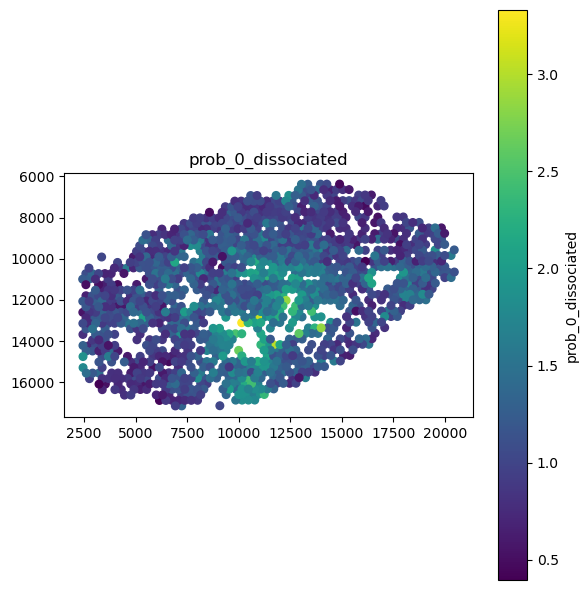

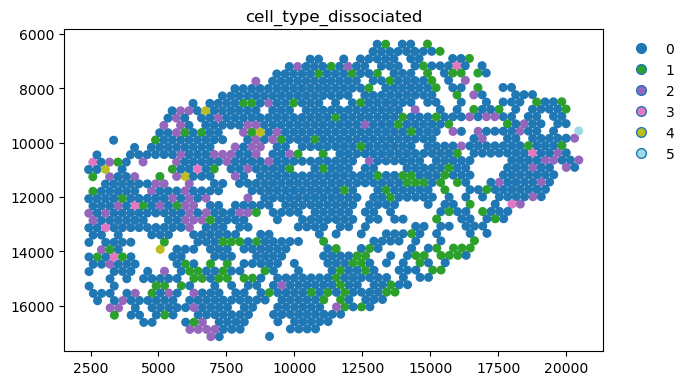

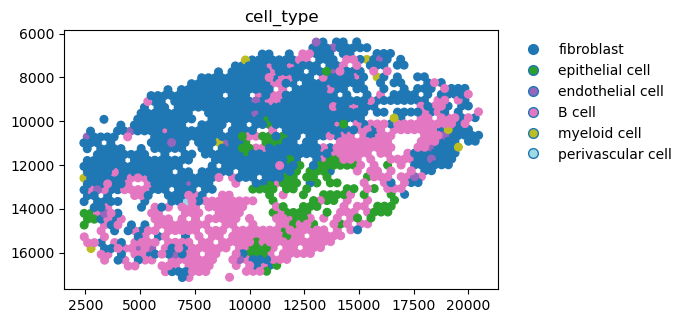

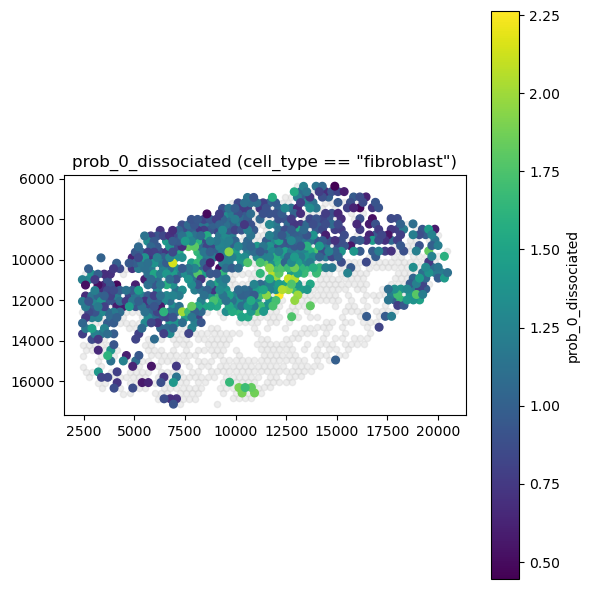

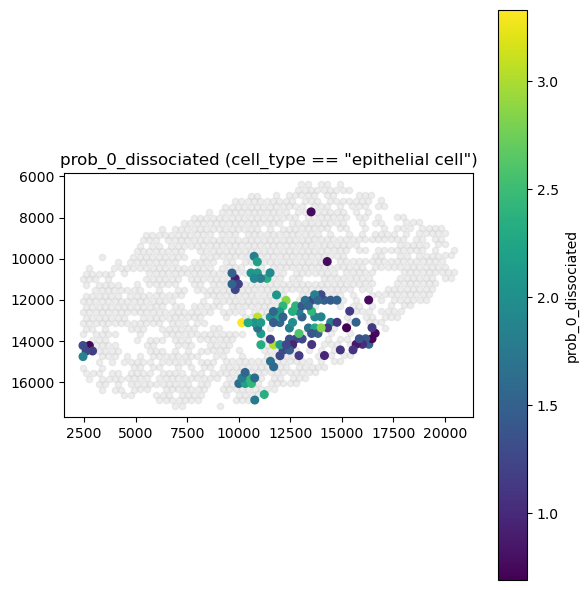

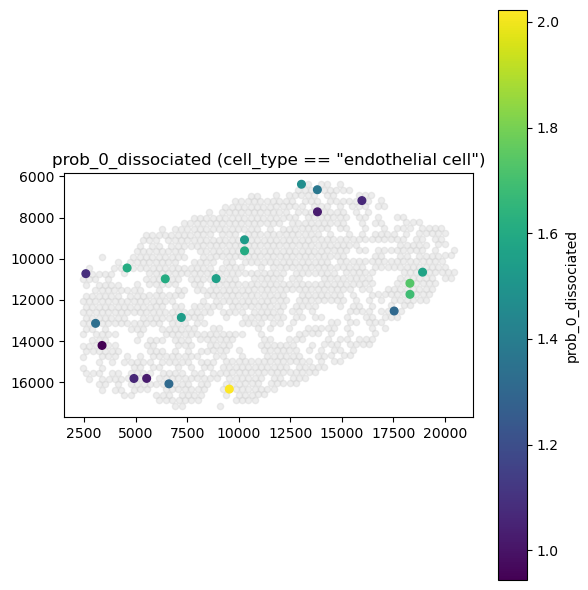

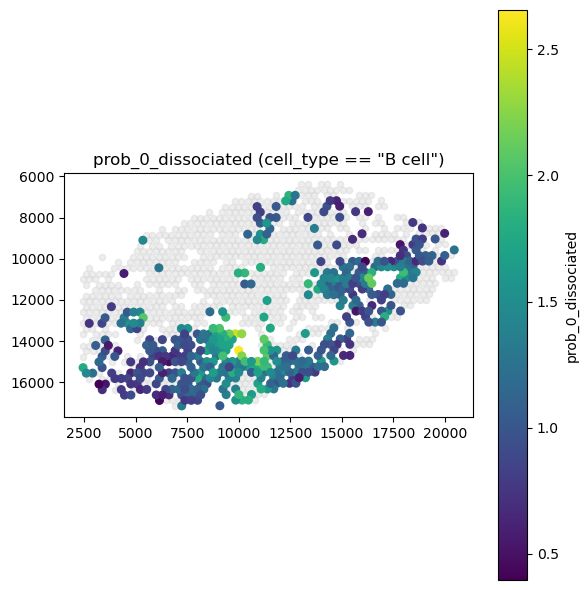

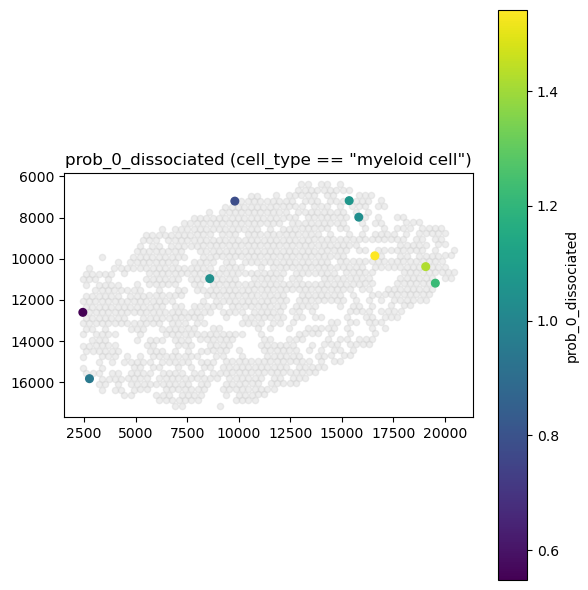

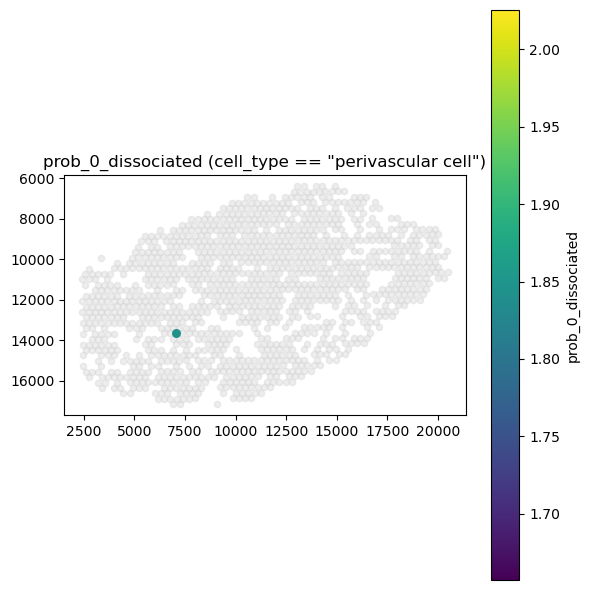

In [22]:
plot_ct_map(ct_pred="0")